In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy import stats
import rasterio, numpy as np, matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from scipy import stats
import rasterio

# Distribution plot

C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_69844\2023967140.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  italy_geom = world[world["NAME"] == "Italy"].geometry.unary_union


EU (train+val): 50,340 pixels
Train:          40,271
Val:            10,069
Test (Italy):   3,316
Weibull: k=0.853, lambda=0.031
Power law exponent (alpha): 2.783


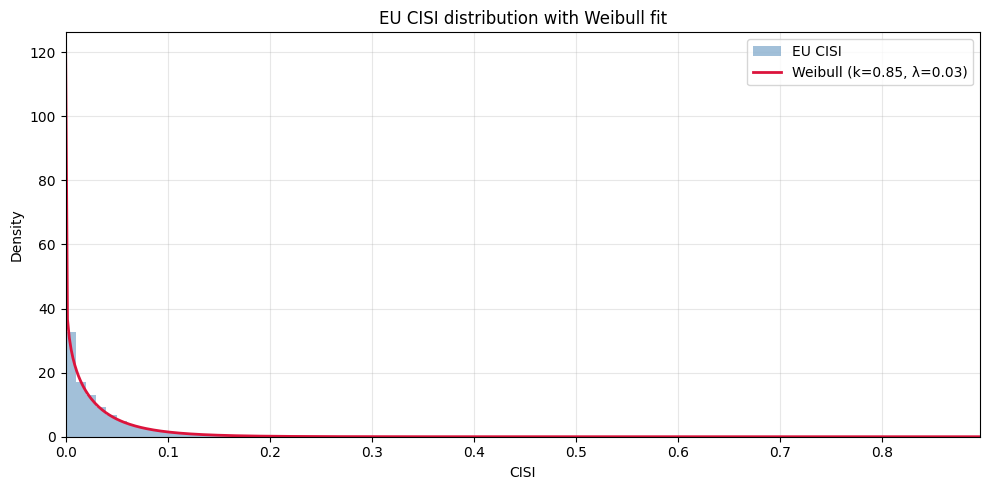

In [79]:


cisi_path    = r"READY_data/labels/2024_CISI_010deg_nearest.tif"
eu_mask_path = r"READY_data/labels/eu_mask_010deg_ex_italy.tif"

with rasterio.open(cisi_path) as src:
    cisi_full = src.read(1).astype("float32")
    transform = src.transform

with rasterio.open(eu_mask_path) as src:
    eu_mask = src.read(1).astype(bool)

# EU pixels (training domain, Italy excluded)
eu_valid = eu_mask & ~np.isnan(cisi_full)
eu_vals  = cisi_full[eu_valid]

# Italy pixels (test set)
world = gpd.read_file(r"ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")[["NAME","geometry"]]
italy_geom = world[world["NAME"] == "Italy"].geometry.unary_union
outside_eu_idx = np.argwhere(~eu_mask & ~np.isnan(cisi_full))
xs, ys = rasterio.transform.xy(transform, outside_eu_idx[:,0], outside_eu_idx[:,1])
is_italy = np.array([italy_geom.contains(Point(x, y)) for x, y in zip(xs, ys)])
italy_vals = cisi_full[outside_eu_idx[is_italy,0], outside_eu_idx[is_italy,1]]

# Stratified 80/20 split (same as training)
high_idx = np.where(eu_vals > 0.15)[0]
low_idx  = np.where(eu_vals <= 0.15)[0]
rng = np.random.RandomState(42)
rng.shuffle(high_idx); rng.shuffle(low_idx)
train_idx  = np.concatenate([high_idx[:int(0.8*len(high_idx))], low_idx[:int(0.8*len(low_idx))]])
val_idx    = np.concatenate([high_idx[int(0.8*len(high_idx)):],  low_idx[int(0.8*len(low_idx)):]])
train_vals = eu_vals[train_idx]
val_vals   = eu_vals[val_idx]

print(f"EU (train+val): {len(eu_vals):,} pixels")
print(f"Train:          {len(train_vals):,}")
print(f"Val:            {len(val_vals):,}")
print(f"Test (Italy):   {len(italy_vals):,}")

# Fit Weibull and Power law to EU distribution (non-zero)
eu_nonzero = eu_vals[eu_vals > 0]

shape_w, loc_w, scale_w = stats.weibull_min.fit(eu_nonzero, floc=0)
print(f"Weibull: k={shape_w:.3f}, lambda={scale_w:.3f}")

sorted_desc = np.sort(eu_nonzero)[::-1]
ranks = np.arange(1, len(sorted_desc)+1)
log_x = np.log10(sorted_desc[:int(len(sorted_desc)*0.1)])
log_y = np.log10(ranks[:int(len(sorted_desc)*0.1)] / len(eu_nonzero))
pl_slope, pl_intercept = np.polyfit(log_x, log_y, 1)[:2]
print(f"Power law exponent (alpha): {-pl_slope:.3f}")

# Plot: histogram + Weibull fit
nonzero_frac = len(eu_nonzero) / len(eu_vals)
x_line = np.linspace(1e-6, eu_vals.max(), 500)
bin_width = 0.01
bins = np.arange(0, eu_vals.max() + bin_width, bin_width)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(eu_vals, bins=bins, density=True, color="steelblue", alpha=0.5, label="EU CISI")

# Scale Weibull PDF by non-zero fraction so it overlays correctly
weib_pdf = stats.weibull_min.pdf(x_line, shape_w, loc_w, scale_w) * nonzero_frac
ax.plot(x_line, weib_pdf, color="crimson", lw=2, label=f"Weibull (k={shape_w:.2f}, λ={scale_w:.2f})")

ax.set_xlim(0, eu_vals.max())
ax.set_xlabel("CISI"); ax.set_ylabel("Density")
ax.set_title("EU CISI distribution with Weibull fit")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


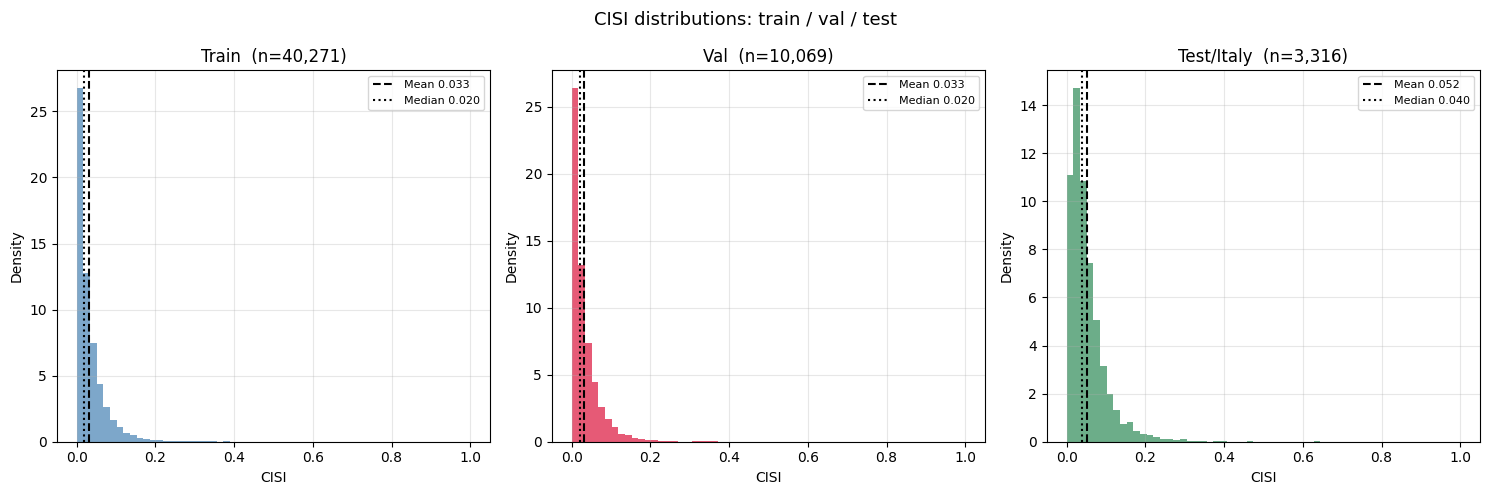

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bins = np.linspace(0, 1, 60)

for ax, vals, label, color in zip(
    axes,
    [train_vals, val_vals, italy_vals],
    [f"Train  (n={len(train_vals):,})", f"Val  (n={len(val_vals):,})", f"Test/Italy  (n={len(italy_vals):,})"],
    ["steelblue", "crimson", "seagreen"]
):
    ax.hist(vals, bins=bins, density=True, color=color, alpha=0.7, edgecolor="none")
    ax.axvline(vals.mean(),              color="black", lw=1.5, linestyle="--", label=f"Mean {vals.mean():.3f}")
    ax.axvline(float(np.median(vals)),   color="black", lw=1.5, linestyle=":",  label=f"Median {float(np.median(vals)):.3f}")
    ax.set_title(label)
    ax.set_xlabel("CISI"); ax.set_ylabel("Density")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("CISI distributions: train / val / test", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
data = eu_nonzero

distributions = {
    'Weibull':     stats.weibull_min,
    'Log-normal':  stats.lognorm,
    'Exponential': stats.expon,
    'Power law':   stats.powerlaw,
}

fixed = {
    'Weibull':     dict(floc=0),
    'Exponential': dict(floc=0),
    'Power law':   dict(floc=0, fscale=1),
}

fits = {}
print('{:<15} {:>10} {:>10} {:>10} {:>10}'.format('Distribution','AIC','BIC','KS stat','KS p'))
print('-' * 58)
for name, dist in distributions.items():
    try:
        params = dist.fit(data, **fixed.get(name, {}))
        ll  = dist.logpdf(data, *params).sum()
        k   = len(params)
        n   = len(data)
        aic = 2*k - 2*ll
        bic = k*np.log(n) - 2*ll
        ks, pval = stats.kstest(data, dist.cdf, args=params)
        fits[name] = dict(params=params, aic=aic, bic=bic, ks=ks, pval=pval, dist=dist)
        print('{:<15} {:>10.1f} {:>10.1f} {:>10.4f} {:>10.4f}'.format(name, aic, bic, ks, pval))
    except Exception as e:
        print(name, 'failed:', e)

best = min(fits, key=lambda k: fits[k]['aic'])
print('Best fit by AIC:', best)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, f) in zip(axes.flatten(), fits.items()):
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist=f['dist'], sparams=f['params'], fit=True)
    ax.scatter(osm, osr, s=2, alpha=0.3, color='steelblue')
    ax.plot([osm.min(), osm.max()],
            [slope*osm.min()+intercept, slope*osm.max()+intercept],
            color='crimson', lw=1.5)
    ax.set_title(name + '\nAIC=' + str(round(f['aic'])))
    ax.set_xlabel('Theoretical quantiles')
    ax.set_ylabel('Sample quantiles')
    ax.grid(alpha=0.3)

plt.suptitle('Q-Q plots - CISI non-zero EU pixels', fontsize=12)
plt.tight_layout()
plt.show()

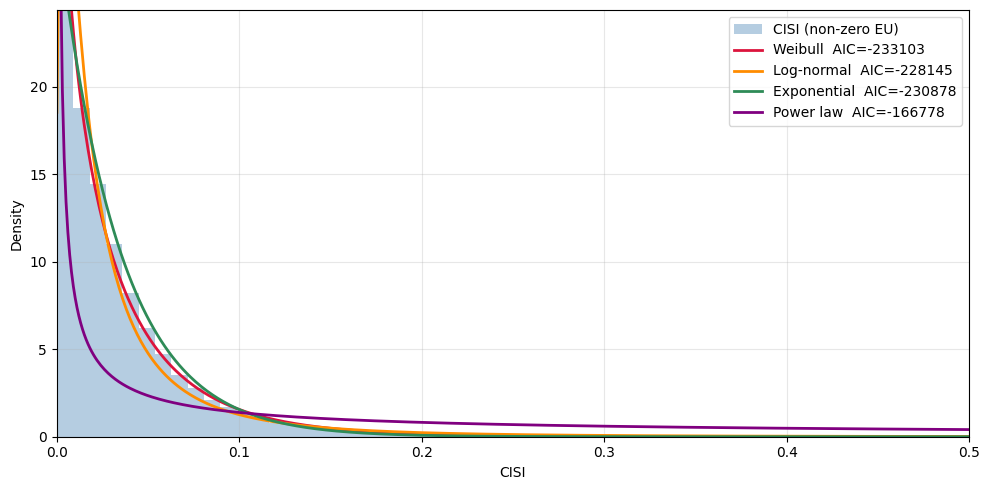

In [93]:
x = np.linspace(1e-6, 0.5, 500)
colors = {'Weibull': 'crimson', 'Log-normal': 'darkorange', 'Exponential': 'seagreen', 'Power law': 'purple'}

fig, ax = plt.subplots(figsize=(10, 5))
counts, bin_edges, _ = ax.hist(data, bins=100, density=True, color='steelblue', alpha=0.4, label='CISI (non-zero EU)')

for name, f in fits.items():
    pdf = f['dist'].pdf(x, *f['params'])
    ax.plot(x, pdf, color=colors[name], lw=2, label=name + '  AIC=' + str(round(f['aic'])))

ymax = counts[1:].max() * 1.3
ax.set_ylim(0, ymax)
ax.set_xlim(0, 0.5)
ax.set_xlabel('CISI')
ax.set_ylabel('Density')
ax.set_title('')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Power Law

In [82]:
# # Filter out zeros for power law analysis
# cisi_nonzero = df[df['CISI'] > 0]['CISI']

# print(f"Total pixels: {len(df):,}")
# print(f"Non-zero CISI: {len(cisi_nonzero):,} ({len(cisi_nonzero)/len(df)*100:.1f}%)")
# print(f"Zero CISI: {(df['CISI'] == 0).sum():,}")

# # Log-log plot to check for power law
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# # 1. Log-log histogram
# ax1 = axes[0]
# counts, bins, _ = ax1.hist(cisi_nonzero, bins=50, edgecolor='black', alpha=0.7)
# ax1.set_xscale('log')
# ax1.set_yscale('log')
# ax1.set_xlabel('CISI Score (log)')
# ax1.set_ylabel('Frequency (log)')
# ax1.set_title('Log-Log Distribution\n(Power law shows as straight line)')
# ax1.grid(alpha=0.3)

# # 2. Rank-frequency plot (Zipf plot)
# ax2 = axes[1]
# sorted_cisi = np.sort(cisi_nonzero)[::-1]  # Descending
# ranks = np.arange(1, len(sorted_cisi) + 1)
# ax2.loglog(ranks, sorted_cisi, 'o', markersize=2, alpha=0.5)
# ax2.set_xlabel('Rank (log)')
# ax2.set_ylabel('CISI Score (log)')
# ax2.set_title('Rank-Frequency Plot (Zipf)\n(Power law shows as straight line)')
# ax2.grid(alpha=0.3)

# # Fit power law to tail (top 10%)
# tail_size = int(len(sorted_cisi) * 0.1)
# tail_ranks = ranks[:tail_size]
# tail_cisi = sorted_cisi[:tail_size]

# # Log-log linear fit
# log_ranks = np.log10(tail_ranks)
# log_cisi = np.log10(tail_cisi)
# slope, intercept = np.polyfit(log_ranks, log_cisi, 1)
# ax2.loglog(tail_ranks, 10**(intercept + slope * np.log10(tail_ranks)), 
#            'r-', linewidth=2, label=f'Power law fit: α={-slope:.2f}')
# ax2.legend()

# # 3. Q-Q plot against power law
# ax3 = axes[2]
# stats.probplot(np.log10(cisi_nonzero), dist="norm", plot=ax3)
# ax3.set_title('Q-Q Plot (Log-transformed CISI)')
# ax3.grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig('cisi_power_law_analysis.png', dpi=300, bbox_inches='tight')
# plt.show()

# print(f"\n{'='*80}")
# print("POWER LAW ANALYSIS")
# print(f"{'='*80}")
# print(f"Power law exponent (α): {-slope:.3f}")
# print(f"(α ≈ 2-3 indicates typical city size distribution)")
# print(f"\nInterpretation:")
# if -slope > 2.5:
#     print("  → Distribution more concentrated in few large cities")
# elif -slope < 1.5:
#     print("  → Distribution more uniform across cities")
# else:
#     print("  → Typical urban hierarchy (Zipf's law)")

In [83]:
# import pandas as pd
# import numpy as np
# from scipy import stats
# from scipy.optimize import curve_fit

# # Load data
# df = pd.read_feather(r'READY_data\labels\CISI_exposure_Europe_025deg.feather')
# cisi_nonzero = df[df['CISI'] > 0]['CISI'].values

# print(f"{'='*80}")
# print("STATISTICAL DISTRIBUTION ANALYSIS")
# print(f"{'='*80}")

# # ============================================================================
# # 1. POWER LAW FIT
# # ============================================================================
# print("\n1. POWER LAW ANALYSIS")
# print("-" * 80)

# # Use only tail (top 10% for cleaner fit)
# sorted_cisi = np.sort(cisi_nonzero)[::-1]
# tail_size = int(len(sorted_cisi) * 0.1)
# tail_cisi = sorted_cisi[:tail_size]

# # Fit: P(X > x) ~ x^(-α)
# # Use complementary CDF
# ccdf = np.arange(1, len(tail_cisi) + 1) / len(cisi_nonzero)

# # Log-log linear regression
# log_x = np.log10(tail_cisi)
# log_y = np.log10(ccdf)
# slope, intercept, r_value, p_value, std_err = stats.linregress(log_x, log_y)
# alpha = -slope

# print(f"Power law exponent (α): {alpha:.3f}")
# print(f"R² of log-log fit: {r_value**2:.4f}")
# print(f"p-value: {p_value:.4e}")

# # Kolmogorov-Smirnov test for power law
# from scipy.stats import kstest
# def power_law_cdf(x, alpha, xmin):
#     return 1 - (x / xmin) ** (1 - alpha)

# xmin = tail_cisi.min()
# ks_stat, ks_pval = kstest(tail_cisi, lambda x: power_law_cdf(x, alpha, xmin))
# print(f"KS test statistic: {ks_stat:.4f}")
# print(f"KS p-value: {ks_pval:.4f}")
# print(f"  → {'REJECT' if ks_pval < 0.05 else 'FAIL TO REJECT'} power law (α=0.05)")

# # ============================================================================
# # 2. LOG-NORMAL FIT
# # ============================================================================
# print("\n2. LOG-NORMAL DISTRIBUTION")
# print("-" * 80)

# log_cisi = np.log(cisi_nonzero)
# mu, sigma = log_cisi.mean(), log_cisi.std()

# print(f"Log-normal parameters:")
# print(f"  μ (log mean): {mu:.4f}")
# print(f"  σ (log std): {sigma:.4f}")
# print(f"  Median (e^μ): {np.exp(mu):.4f}")
# print(f"  Mode (e^(μ-σ²)): {np.exp(mu - sigma**2):.4f}")

# # Anderson-Darling test
# ad_stat, ad_crit, ad_sig = stats.anderson(log_cisi, dist='norm')
# print(f"\nAnderson-Darling test:")
# print(f"  Statistic: {ad_stat:.4f}")
# for i, (crit, sig) in enumerate(zip(ad_crit, ad_sig)):
#     result = "REJECT" if ad_stat > crit else "FAIL TO REJECT"
#     print(f"  {sig}% significance: {crit:.3f} → {result} log-normal")

# # ============================================================================
# # 3. EXPONENTIAL FIT
# # ============================================================================
# print("\n3. EXPONENTIAL DISTRIBUTION")
# print("-" * 80)

# # MLE for exponential: λ = 1/mean
# lambda_exp = 1 / cisi_nonzero.mean()
# print(f"Rate parameter (λ): {lambda_exp:.4f}")
# print(f"Mean: {1/lambda_exp:.4f}")

# # KS test for exponential
# ks_exp, pval_exp = stats.kstest(cisi_nonzero, 'expon', args=(0, 1/lambda_exp))
# print(f"KS test statistic: {ks_exp:.4f}")
# print(f"KS p-value: {pval_exp:.4f}")
# print(f"  → {'REJECT' if pval_exp < 0.05 else 'FAIL TO REJECT'} exponential")

# # ============================================================================
# # 4. PARETO FIT (alternative power law)
# # ============================================================================
# print("\n4. PARETO DISTRIBUTION")
# print("-" * 80)

# # Fit Pareto: P(X > x) = (xmin/x)^α
# xmin_pareto = cisi_nonzero.min()
# alpha_pareto = 1 + len(cisi_nonzero) / np.sum(np.log(cisi_nonzero / xmin_pareto))

# print(f"Shape parameter (α): {alpha_pareto:.4f}")
# print(f"Scale (xmin): {xmin_pareto:.4f}")
# print(f"Mean: {alpha_pareto * xmin_pareto / (alpha_pareto - 1) if alpha_pareto > 1 else 'undefined':.4f}")

# # ============================================================================
# # 5. WEIBULL FIT
# # ============================================================================
# print("\n5. WEIBULL DISTRIBUTION")
# print("-" * 80)

# shape_w, loc_w, scale_w = stats.weibull_min.fit(cisi_nonzero, floc=0)
# print(f"Shape (k): {shape_w:.4f}")
# print(f"Scale (λ): {scale_w:.4f}")

# ks_weib, pval_weib = stats.kstest(cisi_nonzero, 'weibull_min', args=(shape_w, loc_w, scale_w))
# print(f"KS test statistic: {ks_weib:.4f}")
# print(f"KS p-value: {pval_weib:.4f}")

# # ============================================================================
# # 6. COMPARE ALL DISTRIBUTIONS (AIC/BIC)
# # ============================================================================
# print("\n6. MODEL COMPARISON (AIC/BIC)")
# print("-" * 80)

# def compute_aic_bic(log_likelihood, n_params, n_data):
#     aic = 2 * n_params - 2 * log_likelihood
#     bic = n_params * np.log(n_data) - 2 * log_likelihood
#     return aic, bic

# n = len(cisi_nonzero)

# # Log-likelihood for each distribution
# ll_lognorm = np.sum(stats.lognorm.logpdf(cisi_nonzero, sigma, scale=np.exp(mu)))
# ll_exp = np.sum(stats.expon.logpdf(cisi_nonzero, scale=1/lambda_exp))
# ll_weib = np.sum(stats.weibull_min.logpdf(cisi_nonzero, shape_w, loc_w, scale_w))

# aic_ln, bic_ln = compute_aic_bic(ll_lognorm, 2, n)
# aic_exp, bic_exp = compute_aic_bic(ll_exp, 1, n)
# aic_weib, bic_weib = compute_aic_bic(ll_weib, 2, n)

# print(f"{'Distribution':<20} {'AIC':>12} {'BIC':>12} {'Log-Likelihood':>15}")
# print("-" * 60)
# print(f"{'Log-Normal':<20} {aic_ln:>12.2f} {bic_ln:>12.2f} {ll_lognorm:>15.2f}")
# print(f"{'Exponential':<20} {aic_exp:>12.2f} {bic_exp:>12.2f} {ll_exp:>15.2f}")
# print(f"{'Weibull':<20} {aic_weib:>12.2f} {bic_weib:>12.2f} {ll_weib:>15.2f}")
# print("\n(Lower AIC/BIC = better fit)")

# best_aic = min(aic_ln, aic_exp, aic_weib)
# if best_aic == aic_ln:
#     print("\n→ BEST FIT: Log-Normal distribution")
# elif best_aic == aic_exp:
#     print("\n→ BEST FIT: Exponential distribution")
# else:
#     print("\n→ BEST FIT: Weibull distribution")

# # ============================================================================
# # 7. HEAVY-TAIL TEST
# # ============================================================================
# print("\n7. HEAVY-TAIL CHARACTERISTICS")
# print("-" * 80)

# # Kurtosis (excess kurtosis > 0 indicates heavy tails)
# kurtosis = stats.kurtosis(cisi_nonzero)
# print(f"Excess kurtosis: {kurtosis:.4f}")
# print(f"  → {'Heavy-tailed' if kurtosis > 3 else 'Light-tailed' if kurtosis < 0 else 'Moderate'}")

# # Tail index (Hill estimator for upper tail)
# k_tail = 100  # Top 100 observations
# sorted_desc = np.sort(cisi_nonzero)[::-1]
# hill_estimator = np.mean(np.log(sorted_desc[:k_tail] / sorted_desc[k_tail]))
# tail_index = 1 / hill_estimator

# print(f"Hill estimator (α): {tail_index:.4f}")
# print(f"  → α > 2: Heavy tail (infinite variance)")

# Cities

In [84]:
# import pandas as pd
# import geopandas as gpd
# from shapely import wkb

# # Load feather
# df = pd.read_feather(r'READY_data\labels\CISI_exposure_Europe_025deg.feather')

# # Convert geometry from WKB to actual geometries
# gdf = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkb(df['geometry']))
# gdf = gdf.set_crs('EPSG:4326')

# # Get top 20
# top20 = gdf.nlargest(20, 'CISI').copy()

# # Extract centroids (lat/lon)
# top20['longitude'] = top20.geometry.centroid.x
# top20['latitude'] = top20.geometry.centroid.y

# # Display
# print(f"{'='*80}")
# print("TOP 20 HIGHEST CISI LOCATIONS")
# print(f"{'='*80}")
# print(f"{'Rank':<6} {'CISI':<8} {'Latitude':<12} {'Longitude':<12}")
# print("-" * 80)

# for rank, (idx, row) in enumerate(top20.iterrows(), 1):
#     print(f"{rank:<6} {row['CISI']:<8.4f} {row['latitude']:<12.4f} {row['longitude']:<12.4f}")

# # Use reverse geocoding to get city names (requires geopy)
# try:
#     from geopy.geocoders import Nominatim
#     from time import sleep
    
#     print(f"\n{'='*80}")
#     print("IDENTIFYING CITIES (this may take a minute...)")
#     print(f"{'='*80}")
    
#     geolocator = Nominatim(user_agent="cisi_analysis")
    
#     cities = []
#     for rank, (idx, row) in enumerate(top20.iterrows(), 1):
#         try:
#             location = geolocator.reverse(f"{row['latitude']}, {row['longitude']}", language='en')
            
#             # Extract city name from address
#             address = location.raw.get('address', {})
#             city = (address.get('city') or 
#                    address.get('town') or 
#                    address.get('village') or 
#                    address.get('municipality') or
#                    address.get('county') or
#                    'Unknown')
#             country = address.get('country', 'Unknown')
            
#             cities.append({
#                 'Rank': rank,
#                 'CISI': row['CISI'],
#                 'City': city,
#                 'Country': country,
#                 'Lat': row['latitude'],
#                 'Lon': row['longitude']
#             })
            
#             print(f"{rank:<4} {row['CISI']:.4f}  {city:<25} {country}")
#             sleep(1.1)  # Rate limit: max 1 request/sec
            
#         except Exception as e:
#             print(f"{rank:<4} {row['CISI']:.4f}  [Geocoding failed]")
#             cities.append({
#                 'Rank': rank,
#                 'CISI': row['CISI'],
#                 'City': 'Error',
#                 'Country': 'Error',
#                 'Lat': row['latitude'],
#                 'Lon': row['longitude']
#             })
    
#     # Save to CSV
#     cities_df = pd.DataFrame(cities)
#     cities_df.to_csv('top20_cisi_cities.csv', index=False)
#     print(f"\nSaved to: top20_cisi_cities.csv")
    
# except ImportError:
#     print("\nInstall geopy for automatic city identification:")
#     print("  pip install geopy")
#     print("\nOr manually check coordinates at: https://www.google.com/maps")

# Removed pixels analysis

Compares the old training mask (all CISI-valid pixels, 87k) against the new EU27 mask (excl. Italy, 50k).
Shows what CISI values were in the removed pixels so we understand what the model no longer trains on.

In [ ]:
CISI_PATH    = r'READY_data/labels/2024_CISI_010deg_nearest.tif'
EU_MASK_PATH = r'READY_data/labels/eu_mask_010deg_ex_italy.tif'
SHP_PATH     = r'ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp'

with rasterio.open(CISI_PATH) as src:
    cisi      = src.read(1).astype(np.float32)
    transform = src.transform
    bounds    = src.bounds

with rasterio.open(EU_MASK_PATH) as src:
    eu_mask = src.read(1).astype(bool)

old_mask     = ~np.isnan(cisi)                  # 87k pixels
new_mask     = eu_mask                           # 50k pixels
removed_mask = old_mask & ~new_mask              # pixels in old but not new

print('Old mask (CISI valid):   ', old_mask.sum())
print('New mask (EU27 excl. IT):', new_mask.sum())
print('Removed pixels:          ', removed_mask.sum())

removed_vals = cisi[removed_mask]
print()
print('Removed pixel CISI stats:')
print('  Mean: ', round(float(removed_vals.mean()), 4))
print('  Max:  ', round(float(removed_vals.max()), 4))
print('  % > 0.15:', round(float((removed_vals > 0.15).mean() * 100), 1), '%')
print('  % > 0.30:', round(float((removed_vals > 0.30).mean() * 100), 1), '%')


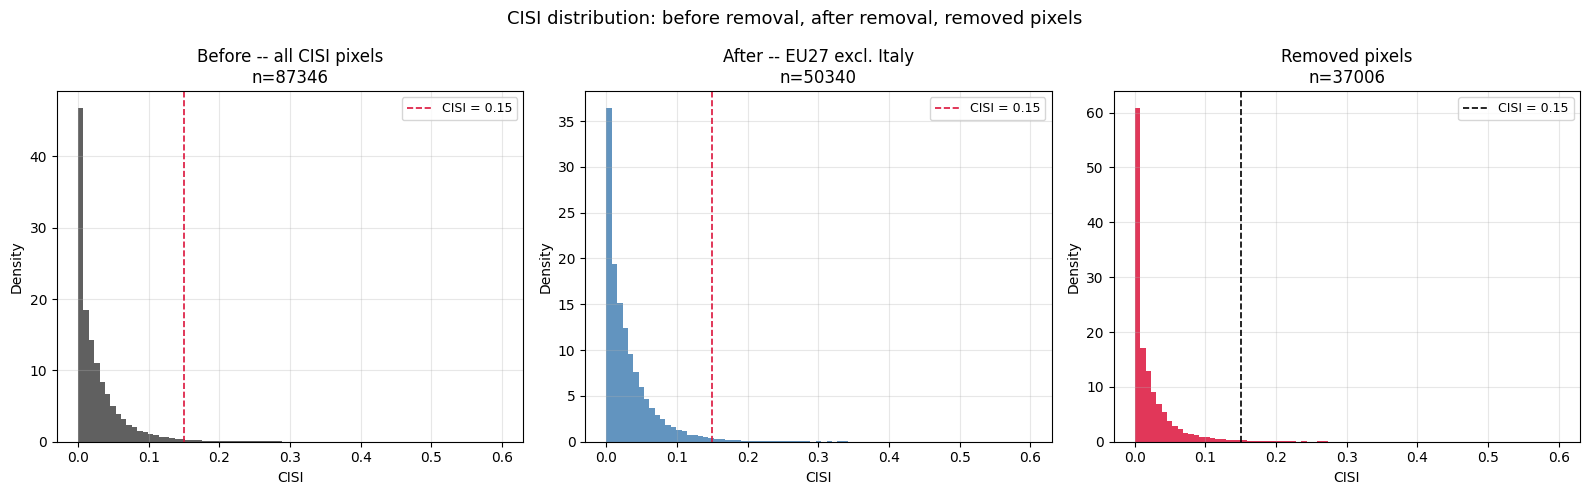

Saved figures/removed_pixels_distribution.png
Before -- mean: 0.0284  max: 0.8959  %>0.15: 1.8
After  -- mean: 0.0327  max: 0.8959  %>0.15: 2.0
Removed-- mean: 0.0225  max: 0.6342  %>0.15: 1.5


In [86]:
world = gpd.read_file(SHP_PATH)
ext   = [bounds.left, bounds.right, bounds.bottom, bounds.top]

kept_vals    = cisi[new_mask]
removed_vals = cisi[removed_mask]
all_vals     = cisi[old_mask]

bins = np.linspace(0, 0.6, 80)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('CISI distribution: before removal, after removal, removed pixels', fontsize=13)

ax = axes[0]
ax.hist(all_vals, bins=bins, color='#444444', density=True, alpha=0.85)
ax.axvline(0.15, color='crimson', linestyle='--', linewidth=1.2, label='CISI = 0.15')
ax.set_title('Before -- all CISI pixels\nn=' + str(len(all_vals)))
ax.set_xlabel('CISI'); ax.set_ylabel('Density')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(kept_vals, bins=bins, color='steelblue', density=True, alpha=0.85)
ax.axvline(0.15, color='crimson', linestyle='--', linewidth=1.2, label='CISI = 0.15')
ax.set_title('After -- EU27 excl. Italy\nn=' + str(len(kept_vals)))
ax.set_xlabel('CISI'); ax.set_ylabel('Density')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.hist(removed_vals, bins=bins, color='crimson', density=True, alpha=0.85)
ax.axvline(0.15, color='black', linestyle='--', linewidth=1.2, label='CISI = 0.15')
ax.set_title('Removed pixels\nn=' + str(len(removed_vals)))
ax.set_xlabel('CISI'); ax.set_ylabel('Density')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/removed_pixels_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/removed_pixels_distribution.png')
print('Before -- mean:', round(float(all_vals.mean()),4), ' max:', round(float(all_vals.max()),4), ' %>0.15:', round(float((all_vals>0.15).mean()*100),1))
print('After  -- mean:', round(float(kept_vals.mean()),4), ' max:', round(float(kept_vals.max()),4), ' %>0.15:', round(float((kept_vals>0.15).mean()*100),1))
print('Removed-- mean:', round(float(removed_vals.mean()),4), ' max:', round(float(removed_vals.max()),4), ' %>0.15:', round(float((removed_vals>0.15).mean()*100),1))


In [ ]:
# Per-country breakdown of removed pixels

rows, cols = np.where(removed_mask)
lats = transform[5] + rows * transform[4]
lons = transform[2] + cols * transform[0]
vals = cisi[removed_mask]


points = gpd.GeoDataFrame(
    {'cisi': vals},
    geometry=[Point(lon, lat) for lon, lat in zip(lons, lats)],
    crs='EPSG:4326'
)

world_crs = world.to_crs('EPSG:4326')
joined = gpd.sjoin(points, world_crs[['NAME', 'geometry']], how='left', predicate='within')

summary = joined.groupby('NAME')['cisi'].agg(['count', 'mean', 'max']).reset_index()
summary.columns = ['Country', 'N pixels', 'Mean CISI', 'Max CISI']
summary = summary.sort_values('N pixels', ascending=False)
summary['Mean CISI'] = summary['Mean CISI'].round(4)
summary['Max CISI']  = summary['Max CISI'].round(4)
print(summary.to_string(index=False))
